#Mohamed Ahmed Abd El Motaleb Ahmed         
#محمد احمد عبد المطلب احمد                                       (AI Project)


#PART(A)

##Project

In [ ]:
pip install ucimlrepo

In [ ]:
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier , KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
models = []
training_times = []
accuracies = []
precisions = []
recalls = []
f1_scores = []
notes = []

#Dataset loading

In [ ]:
adult = fetch_ucirepo(id=2)
x1 = adult.data.features
y1 = adult.data.targets

automobile = fetch_ucirepo(id=10)
x2 = automobile.data.features
y2 = automobile.data.targets

#Exploratory Data Analysis


In [ ]:
x1.shape

(48842, 14)

In [ ]:
y1.shape

(48842, 1)

In [ ]:
#Missing value handling
x1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
dtypes: int64(6), object(8)
memory usage: 5.2+ MB


#Outlier detection and treatment

In [ ]:
x1.describe() #The Outliers Are fnlwgt , capital-gain , capital-loss

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


#Encoding categorical variables

In [ ]:
for col in x1.columns:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(x1[col].value_counts(dropna=False)) #I will drop ? and NaN in worlclass , occupation ,  native-country


Column: age
age
36    1348
35    1337
33    1335
23    1329
31    1325
      ... 
88       6
85       5
87       3
89       2
86       1
Name: count, Length: 74, dtype: int64

Column: workclass
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
NaN                   963
Without-pay            21
Never-worked           10
Name: count, dtype: int64

Column: fnlwgt
fnlwgt
203488    21
120277    19
190290    19
126569    18
125892    18
          ..
275677     1
311631     1
374763     1
242136     1
26711      1
Name: count, Length: 28523, dtype: int64

Column: education
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate

In [ ]:
#Display the frequency for top value in each object column
for col in x1.select_dtypes(include="object").columns:
    top_freq = x1[col].value_counts(dropna=False).iloc[0]
    percentage = (top_freq / len(x1)) * 100

    print(f"{col}")
    print(f"Top Value      : {x1[col].value_counts(dropna=False).index[0]}")
    print(f"Frequency      : {top_freq}")
    print(f"Percentage     : {percentage:.2f}%")
    print("-" * 40)

workclass
Top Value      : Private
Frequency      : 33906
Percentage     : 69.42%
----------------------------------------
education
Top Value      : HS-grad
Frequency      : 15784
Percentage     : 32.32%
----------------------------------------
marital-status
Top Value      : Married-civ-spouse
Frequency      : 22379
Percentage     : 45.82%
----------------------------------------
occupation
Top Value      : Prof-specialty
Frequency      : 6172
Percentage     : 12.64%
----------------------------------------
relationship
Top Value      : Husband
Frequency      : 19716
Percentage     : 40.37%
----------------------------------------
race
Top Value      : White
Frequency      : 41762
Percentage     : 85.50%
----------------------------------------
sex
Top Value      : Male
Frequency      : 32650
Percentage     : 66.85%
----------------------------------------
native-country
Top Value      : United-States
Frequency      : 43832
Percentage     : 89.74%
------------------------------------

In [ ]:
y1["income"] = y1["income"].str.replace(".", "", regex=False)

/tmp/ipykernel_60503/4121449074.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y1["income"] = y1["income"].str.replace(".", "", regex=False)


In [ ]:
x1.duplicated().sum()

np.int64(53)

In [ ]:
x1.isna().sum()

,0
age,0
workclass,963
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,966
relationship,0
race,0
sex,0


#Normalization or scaling

In [ ]:
fill_values = {} #or fill_values = {"age" : 0 , "workclass" : 963 , "fnlwgt" : 0 , "education" : 0 , "eduction-num" : 0 , "marital-status" : 0 , "occupation" : 966 , "relationship" : 0 , "race" : 0 , "sex" : 0, "capital-gain" : 0 , "capital-loss" : 0 , "hours-per-week" : 0 , "native-country" : 274 } for better optimization

# Replace ? with NaN
x1.replace("?", np.nan, inplace=True)
x1.replace(" ?", np.nan, inplace=True)  # if there are leading spaces

for col in x1.columns: #or fill_values.keys()
    if x1[col].dtype in ["int64", "float64"]:
        fill_values[col] = x1[col].median()
    else:
        fill_values[col] = x1[col].mode()[0]

x1.dropna(subset=["workclass", "occupation", "native-country"], inplace=True)
y1 = y1.loc[x1.index]

x1.fillna(fill_values, inplace = True)

x1.isna().sum()

/tmp/ipykernel_60503/3719005296.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x1.replace("?", np.nan, inplace=True)
/tmp/ipykernel_60503/3719005296.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x1.replace(" ?", np.nan, inplace=True)  # if there are leading spaces
/tmp/ipykernel_60503/3719005296.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x1.dropna(subset=["workclass", "occupation", "native-country"], inplace=True)


,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
for col in x1.columns:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(x1[col].value_counts(dropna=False))


Column: age
age
36    1283
33    1279
31    1274
35    1272
23    1241
      ... 
88       5
85       5
86       1
89       1
87       1
Name: count, Length: 74, dtype: int64

Column: workclass
workclass
Private             33307
Self-emp-not-inc     3796
Local-gov            3100
State-gov            1946
Self-emp-inc         1646
Federal-gov          1406
Without-pay            21
Name: count, dtype: int64

Column: fnlwgt
fnlwgt
203488    21
125892    18
120277    18
126569    17
113364    17
          ..
82720      1
430340     1
344436     1
159691     1
117909     1
Name: count, Length: 26741, dtype: int64

Column: education
education
HS-grad         14783
Some-college     9899
Bachelors        7570
Masters          2514
Assoc-voc        1959
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           823
Prof-school       785
9th               676
12th              577
Doctorate         544
5th-6th           449
1st-4th           222
Preschool          72

In [ ]:
num_cols = x1.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = x1.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [ ]:
data_temp = x1.copy() #each class in target has different medien for each feature
data_temp["target"] = y1

data_temp.groupby("target")[num_cols].median()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
target,,,,,,
<=50K,34.0,178952.5,9.0,0.0,0.0,40.0
>50K,43.0,176775.5,12.0,0.0,0.0,40.0


#Train-test split

In [ ]:
x1_train, x1_test, y1_train, y1_test = train_test_split(
    x1, y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

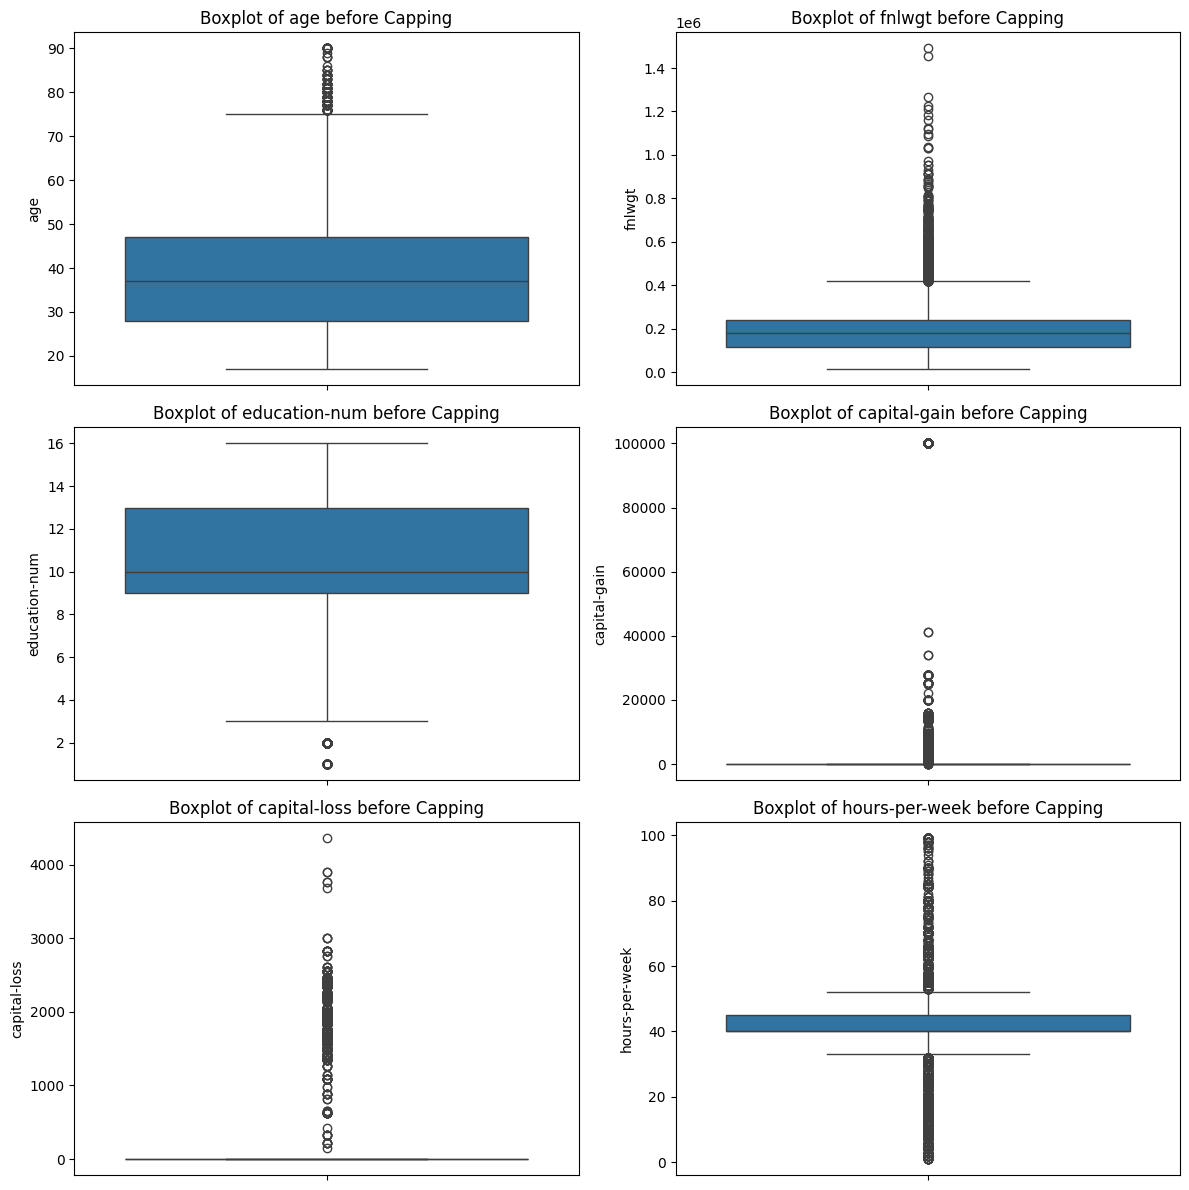

In [ ]:
n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=x1_train[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col} before Capping")
    axes[i].set_ylabel(col)


plt.tight_layout()
plt.show()

#Model training

In [ ]:
outlier_summary = []
outliers_bounds = {}
for col in num_cols:
    Q1 = x1_train[col].quantile(0.25)
    Q3 = x1_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_count = ((x1_train[col] < lower) | (x1_train[col] > upper)).sum()
    outliers_percentage = outliers_count / len(x1_train) * 100
    outliers_bounds[col] = (lower, upper)
    outlier_summary.append({
        "Column": col,
        "Lower Bound": round(lower, 2),
        "Upper Bound": round(upper, 2),
        "Outliers Count": outliers_count,
        "Outliers %": round(outliers_percentage, 2)
    })

pd.DataFrame(outlier_summary).sort_values("Outliers %", ascending=False)

,Column,Lower Bound,Upper Bound,Outliers Count,Outliers %
5,hours-per-week,32.5,52.5,9503,26.27
3,capital-gain,0.0,0.0,3038,8.40
4,capital-loss,0.0,0.0,1736,4.80
1,fnlwgt,-63521.0,419439.0,1054,2.91
2,education-num,3.0,19.0,245,0.68
0,age,-0.5,75.5,209,0.58


In [ ]:
for col in outliers_bounds.keys():
  x1_train[col] = x1_train[col].clip(lower = outliers_bounds[col][0], upper = outliers_bounds[col][1])
  x1_test[col] = x1_test[col].clip(lower = outliers_bounds[col][0], upper = outliers_bounds[col][1])

In [ ]:
outlier_summary = []

for col in num_cols:
    Q1 = x1_train[col].quantile(0.25)
    Q3 = x1_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_count = ((x1_train[col] < lower) | (x1_train[col] > upper)).sum()
    outliers_percentage = outliers_count / len(x1_train) * 100

    outlier_summary.append({
        "Column": col,
        "Lower Bound": round(lower, 2),
        "Upper Bound": round(upper, 2),
        "Outliers Count": outliers_count,
        "Outliers %": round(outliers_percentage, 2)
    })

pd.DataFrame(outlier_summary).sort_values("Outliers %", ascending=False)

,Column,Lower Bound,Upper Bound,Outliers Count,Outliers %
0,age,-0.5,75.5,0,0.0
1,fnlwgt,-63521.0,419439.0,0,0.0
2,education-num,3.0,19.0,0,0.0
3,capital-gain,0.0,0.0,0,0.0
4,capital-loss,0.0,0.0,0,0.0
5,hours-per-week,32.5,52.5,0,0.0


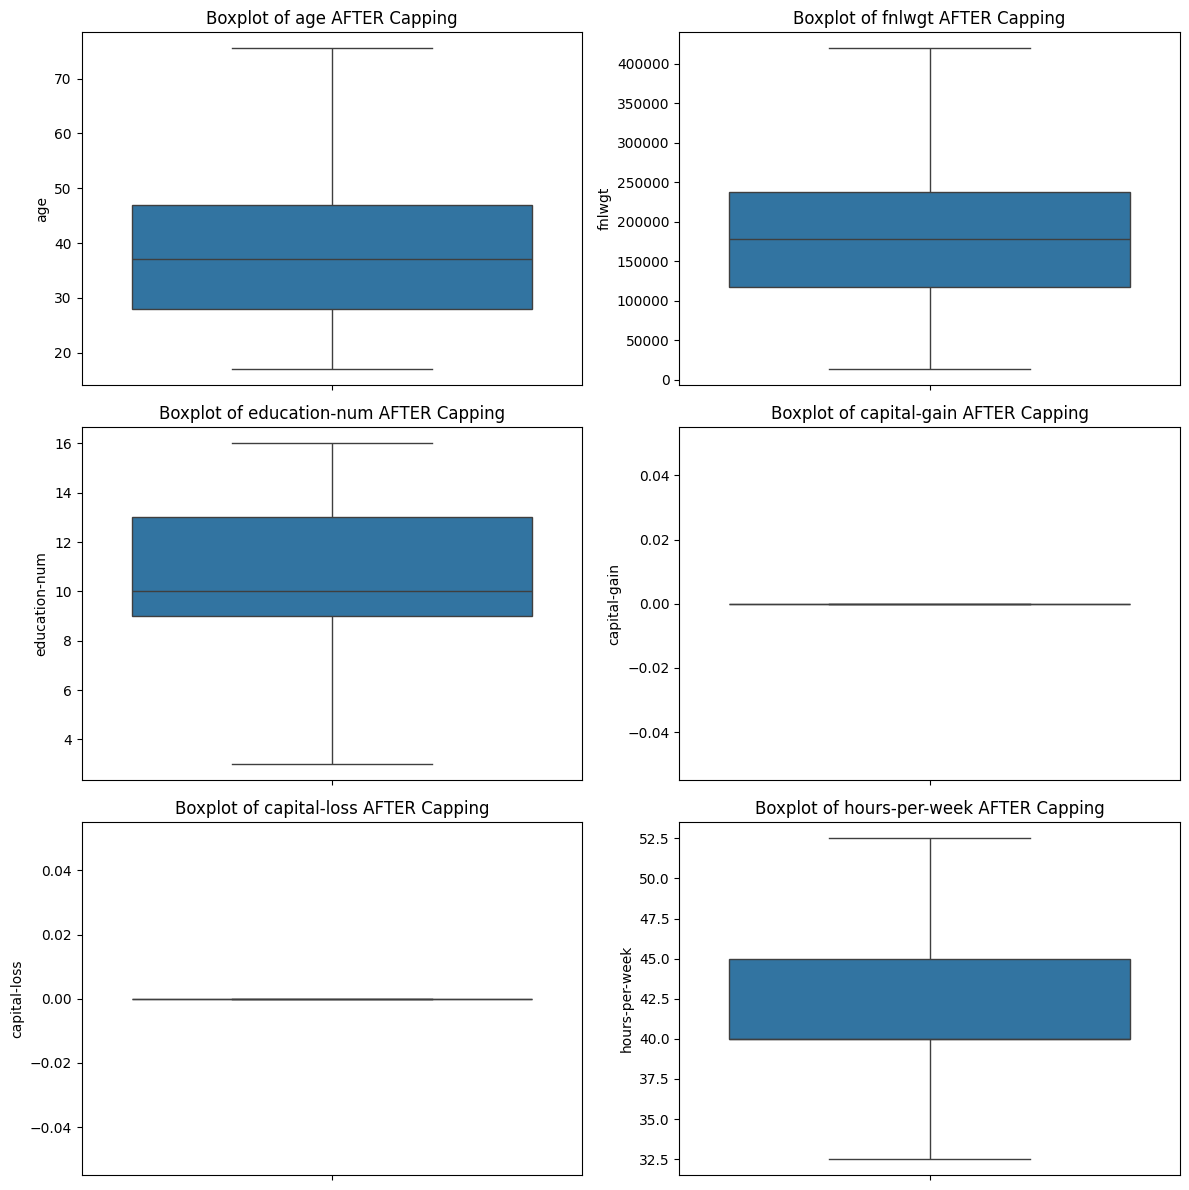

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=x1_train[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col} AFTER Capping")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

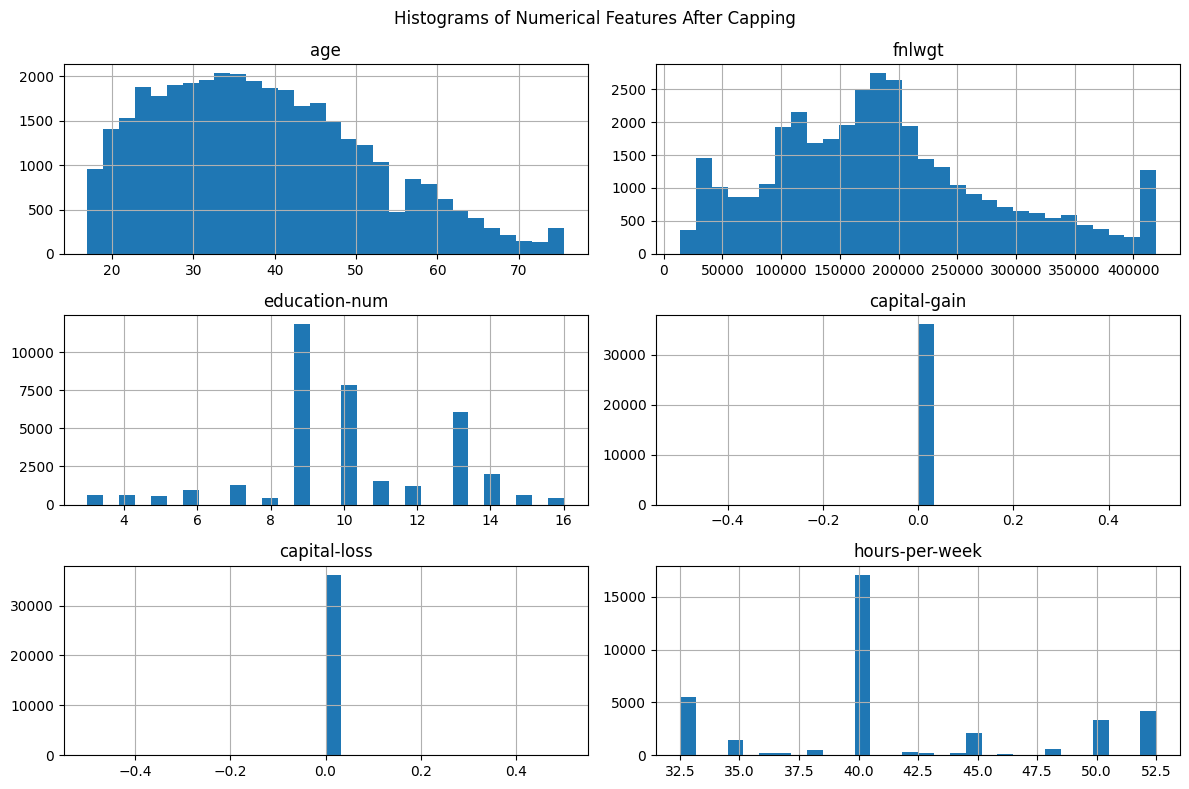

In [ ]:
x1_train[num_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Histograms of Numerical Features After Capping")
plt.tight_layout()
plt.show()

#Model evaluation

In [ ]:
print(x1_train.shape, x1_test.shape)

(36177, 14) (9045, 14)


In [ ]:
x1_train = pd.get_dummies(
    x1_train,
    columns=cat_cols,
    drop_first=True
)

x1_test= pd.get_dummies(
    x1_test,
    columns=cat_cols,
    drop_first=True
)

x1_test = x1_test.reindex(
    columns=x1_train.columns,
    fill_value=0
)

print(x1_train.shape, x1_test.shape)

(36177, 96) (9045, 96)


In [ ]:
scaler = StandardScaler()
x1_train[num_cols] = scaler.fit_transform(x1_train[num_cols])
x1_test[num_cols] = scaler.transform(x1_test[num_cols])

In [ ]:
y1_train = y1_train.values.ravel()
y1_test = y1_test.values.ravel()

In [ ]:
svc = SVC(random_state=42)
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(x1_train, y1_train)
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

Best Cross Validation Accuracy:
0.8360560363352553


In [ ]:
best_svc = grid_search.best_estimator_
cv_scores = cross_val_score(
    best_svc,
    x1_train,
    y1_train,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:")
print(cv_scores)

print("\nMean CV Accuracy:")
print(cv_scores.mean())

CV Scores:
[0.83996683 0.83291874 0.83787146 0.83704216 0.832481  ]

Mean CV Accuracy:
0.8360560363352553


In [ ]:
start_time = time.time()

best_svc.fit(x1_train, y1_train)

training_time = time.time() - start_time

In [ ]:
y1_pred = best_svc.predict(x1_test)

In [ ]:
accuracy = accuracy_score(y1_test, y1_pred)
precision = precision_score(y1_test, y1_pred, average='weighted')
recall = recall_score(y1_test, y1_pred, average='weighted')
f1 = f1_score(y1_test, y1_pred, average='weighted')

print("Accuracy :", round(accuracy, 2))
print("Precision:", round(precision, 2))
print("Recall   :", round(recall, 2))
print("F1 Score :", round(f1, 2))

models.append("SVC")
training_times.append(training_time)
accuracies.append(accuracy)
precisions.append(precision)
recalls.append(recall)
f1_scores.append(f1)
notes.append("Kernel based")

Accuracy : 0.83
Precision: 0.83
Recall   : 0.83
F1 Score : 0.83


In [ ]:
print("""
Comment:
SVC was definitely one of the strongest models here.
Its kernel easily picked up on complex patterns to separate the income classes, resulting in high accuracy, balanced scores, and very few mistakes—all without overfitting the new data.
""")


Comment:
SVC was definitely one of the strongest models here.
Its kernel easily picked up on complex patterns to separate the income classes, resulting in high accuracy, balanced scores, and very few mistakes—all without overfitting the new data.



In [ ]:
print(classification_report(y1_test, y1_pred))

              precision    recall  f1-score   support

       <=50K       0.86      0.93      0.89      6803
        >50K       0.72      0.55      0.62      2242

    accuracy                           0.83      9045
   macro avg       0.79      0.74      0.76      9045
weighted avg       0.83      0.83      0.83      9045



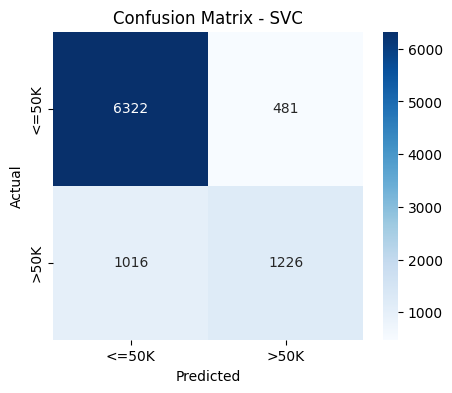

In [ ]:
cm = confusion_matrix(y1_test, y1_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["<=50K", ">50K"],
            yticklabels=["<=50K", ">50K"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVC")
plt.show()


In [ ]:
print(classification_report(y1_test, y1_pred))

              precision    recall  f1-score   support

       <=50K       0.86      0.93      0.89      6803
        >50K       0.72      0.55      0.62      2242

    accuracy                           0.83      9045
   macro avg       0.79      0.74      0.76      9045
weighted avg       0.83      0.83      0.83      9045



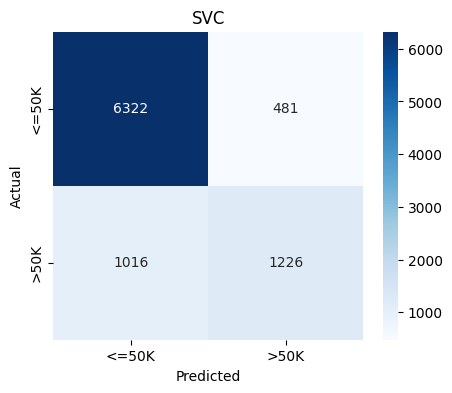

              precision    recall  f1-score   support

       <=50K       0.86      0.93      0.89      6803
        >50K       0.72      0.55      0.62      2242

    accuracy                           0.83      9045
   macro avg       0.79      0.74      0.76      9045
weighted avg       0.83      0.83      0.83      9045



In [ ]:
cm = confusion_matrix(y1_test, y1_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["<=50K", ">50K"],
            yticklabels=["<=50K", ">50K"])

plt.title("SVC")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print(classification_report(y1_test, y1_pred))

In [ ]:
model = LogisticRegression(random_state=42)

start_time = time.time()

model.fit(x1_train, y1_train)

training_time = time.time() - start_time

y1_pred = model.predict(x1_test)

accuracy = accuracy_score(y1_test, y1_pred)
precision = precision_score(y1_test, y1_pred, average="weighted")
recall = recall_score(y1_test, y1_pred, average="weighted")
f1 = f1_score(y1_test, y1_pred, average="weighted")

print("Accuracy :", round(accuracy, 2))
print("Precision:", round(precision, 2))
print("Recall   :", round(recall, 2))
print("F1 Score :", round(f1, 2))

Accuracy : 0.83
Precision: 0.82
Recall   : 0.83
F1 Score : 0.82


In [ ]:
models.append("Logistic Regression")
training_times.append(training_time)
accuracies.append(accuracy)
precisions.append(precision)
recalls.append(recall)
f1_scores.append(f1)
notes.append("Linear model")

In [ ]:
print("""
Comment:
The Logistic Regression model was a solid baseline.
It generalized well without overfitting, keeping precision and recall fairly balanced.
It was slightly better at predicting one income class over the other, but the error rates were pretty low across the board.
""")


Comment:
The Logistic Regression model was a solid baseline.
It generalized well without overfitting, keeping precision and recall fairly balanced.
It was slightly better at predicting one income class over the other, but the error rates were pretty low across the board.



In [ ]:
print(classification_report(y1_test, y1_pred))

              precision    recall  f1-score   support

       <=50K       0.86      0.92      0.89      6803
        >50K       0.69      0.55      0.61      2242

    accuracy                           0.83      9045
   macro avg       0.78      0.74      0.75      9045
weighted avg       0.82      0.83      0.82      9045



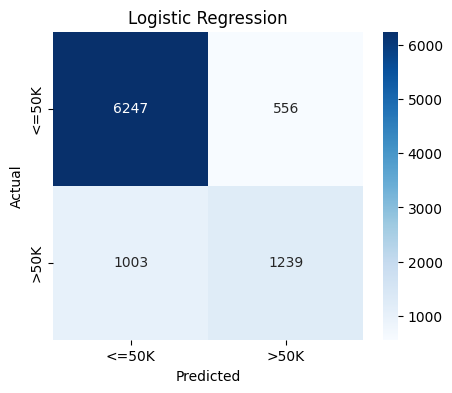

In [ ]:
cm = confusion_matrix(y1_test, y1_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"]
)

plt.title("Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
model = DecisionTreeClassifier(random_state=42)

start_time = time.time()

model.fit(x1_train, y1_train)

training_time = time.time() - start_time

y1_pred = model.predict(x1_test)

accuracy = accuracy_score(y1_test, y1_pred)
precision = precision_score(y1_test, y1_pred, average='weighted')
recall = recall_score(y1_test, y1_pred, average='weighted')
f1 = f1_score(y1_test, y1_pred, average='weighted')


models.append("Decision Tree")
training_times.append(training_time)
accuracies.append(accuracy)
precisions.append(precision)
recalls.append(recall)
f1_scores.append(f1)
notes.append("Tree based")

print("Accuracy :", round(accuracy, 2))
print("Precision:", round(precision, 2))
print("Recall   :", round(recall, 2))
print("F1 Score :", round(f1, 2))

Accuracy : 0.78
Precision: 0.78
Recall   : 0.78
F1 Score : 0.78


In [ ]:
print("""
Comment:
The Decision Tree performed well, offering a great mix of accuracy and interpretability.
It separated the classes effectively, but since standard trees are prone to overfitting, using an ensemble method would be the next best step to improve it.
""")


Comment:
The Decision Tree performed well, offering a great mix of accuracy and interpretability.
It separated the classes effectively, but since standard trees are prone to overfitting, using an ensemble method would be the next best step to improve it.



In [ ]:
print(classification_report(y1_test, y1_pred))

              precision    recall  f1-score   support

       <=50K       0.85      0.85      0.85      6803
        >50K       0.55      0.54      0.55      2242

    accuracy                           0.78      9045
   macro avg       0.70      0.70      0.70      9045
weighted avg       0.78      0.78      0.78      9045



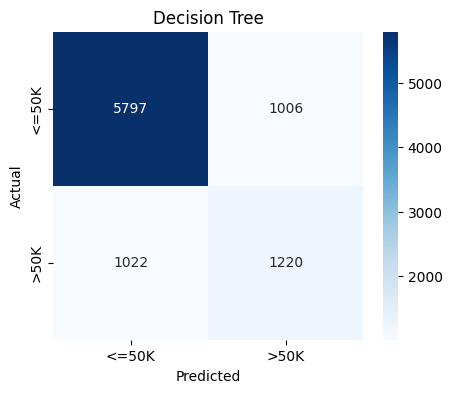

In [ ]:
cm = confusion_matrix(y1_test, y1_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["<=50K", ">50K"],
            yticklabels=["<=50K", ">50K"])

plt.title("Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
model = RandomForestClassifier(random_state=42)

start_time = time.time()

model.fit(x1_train, y1_train)

training_time = time.time() - start_time

y1_pred = model.predict(x1_test)

accuracy = accuracy_score(y1_test, y1_pred)
precision = precision_score(y1_test, y1_pred, average='weighted')
recall = recall_score(y1_test, y1_pred, average='weighted')
f1 = f1_score(y1_test, y1_pred, average='weighted')

models.append("Random Forest")
training_times.append(training_time)
accuracies.append(accuracy)
precisions.append(precision)
recalls.append(recall)
f1_scores.append(f1)
notes.append("Ensemble")

print("Accuracy :", round(accuracy, 2))
print("Precision:", round(precision, 2))
print("Recall   :", round(recall, 2))
print("F1 Score :", round(f1, 2))

Accuracy : 0.82
Precision: 0.82
Recall   : 0.82
F1 Score : 0.82


In [ ]:
print("""
Comment:
Random Forest was easily one of the best models for this dataset.
By combining multiple trees into an ensemble, it kept overfitting in check and generalized perfectly to new data.
Because of this, precision and recall stayed high for both classes, and the error rates dropped significantly.
""")


Comment:
Random Forest was easily one of the best models for this dataset.
By combining multiple trees into an ensemble, it kept overfitting in check and generalized perfectly to new data.
Because of this, precision and recall stayed high for both classes, and the error rates dropped significantly.



In [ ]:
print(classification_report(y1_test, y1_pred))

              precision    recall  f1-score   support

       <=50K       0.86      0.91      0.89      6803
        >50K       0.67      0.56      0.61      2242

    accuracy                           0.82      9045
   macro avg       0.77      0.74      0.75      9045
weighted avg       0.82      0.82      0.82      9045



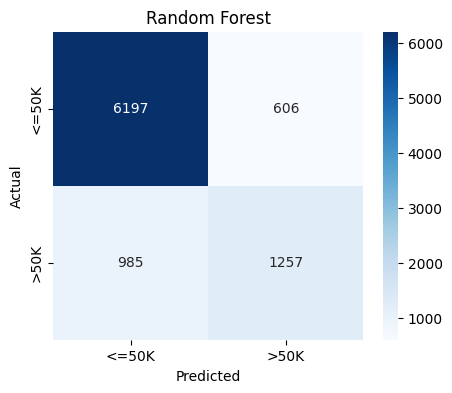

In [ ]:
cm = confusion_matrix(y1_test, y1_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["<=50K", ">50K"],
            yticklabels=["<=50K", ">50K"])

plt.title("Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
model = GradientBoostingClassifier(random_state=42)

start_time = time.time()

model.fit(x1_train, y1_train)

training_time = time.time() - start_time

y1_pred = model.predict(x1_test)

accuracy = accuracy_score(y1_test, y1_pred)
precision = precision_score(y1_test, y1_pred, average='weighted')
recall = recall_score(y1_test, y1_pred, average='weighted')
f1 = f1_score(y1_test, y1_pred, average='weighted')

models.append("Gradient Boosting")
training_times.append(training_time)
accuracies.append(accuracy)
precisions.append(precision)
recalls.append(recall)
f1_scores.append(f1)
notes.append("Boosting")

print("Accuracy :", round(accuracy, 2))
print("Precision:", round(precision, 2))
print("Recall   :", round(recall, 2))
print("F1 Score :", round(f1, 2))

Accuracy : 0.83
Precision: 0.83
Recall   : 0.83
F1 Score : 0.83


In [ ]:
print("""
Comment:
Gradient Boosting was highly effective and delivered great accuracy.
Because it builds trees sequentially to fix previous mistakes, it handled complex relationships really well without losing its ability to generalize.
The precision and recall were strong across both classes, leaving very few errors overall.
""")


Comment:
Gradient Boosting was highly effective and delivered great accuracy.
Because it builds trees sequentially to fix previous mistakes, it handled complex relationships really well without losing its ability to generalize.
The precision and recall were strong across both classes, leaving very few errors overall.



In [ ]:
print(classification_report(y1_test, y1_pred))

              precision    recall  f1-score   support

       <=50K       0.86      0.92      0.89      6803
        >50K       0.71      0.56      0.63      2242

    accuracy                           0.83      9045
   macro avg       0.79      0.74      0.76      9045
weighted avg       0.83      0.83      0.83      9045



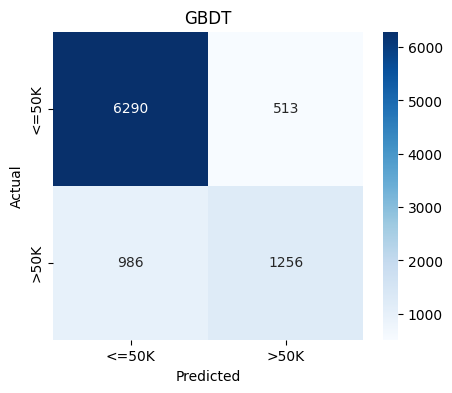

In [ ]:
cm = confusion_matrix(y1_test, y1_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["<=50K", ">50K"],
            yticklabels=["<=50K", ">50K"])

plt.title("GBDT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
model = KNeighborsClassifier(n_neighbors=5)

start_time = time.time()

model.fit(x1_train, y1_train)

training_time = time.time() - start_time

y1_pred = model.predict(x1_test)

accuracy = accuracy_score(y1_test, y1_pred)
precision = precision_score(y1_test, y1_pred, average='weighted')
recall = recall_score(y1_test, y1_pred, average='weighted')
f1 = f1_score(y1_test, y1_pred, average='weighted')

models.append("KNN")
training_times.append(training_time)
accuracies.append(accuracy)
precisions.append(precision)
recalls.append(recall)
f1_scores.append(f1)
notes.append("Instance based")

print("Accuracy :", round(accuracy, 2))
print("Precision:", round(precision, 2))
print("Recall   :", round(recall, 2))
print("F1 Score :", round(f1, 2))

Accuracy : 0.82
Precision: 0.81
Recall   : 0.82
F1 Score : 0.81


In [ ]:
print("""
Comment:
KNN was an effective and reliable instance-based model.
It achieved good accuracy without overfitting, though it still produced a moderate number of errors since its overall performance relies so heavily on proper feature scaling and picking the right number of neighbors.
""")


Comment:
KNN was an effective and reliable instance-based model.
It achieved good accuracy without overfitting, though it still produced a moderate number of errors since its overall performance relies so heavily on proper feature scaling and picking the right number of neighbors.



In [ ]:
model.fit(x1_train, y1_train)

y1_pred = model.predict(x1_test)

accuracy = accuracy_score(y1_test, y1_pred)
precision = precision_score(y1_test, y1_pred, average="weighted")
recall = recall_score(y1_test, y1_pred, average="weighted")
f1 = f1_score(y1_test, y1_pred, average="weighted")

In [ ]:
print(classification_report(y1_test, y1_pred))

              precision    recall  f1-score   support

       <=50K       0.87      0.89      0.88      6803
        >50K       0.64      0.59      0.61      2242

    accuracy                           0.82      9045
   macro avg       0.75      0.74      0.75      9045
weighted avg       0.81      0.82      0.81      9045



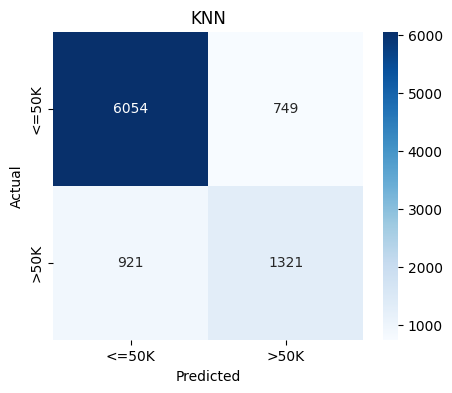

In [ ]:
cm = confusion_matrix(y1_test, y1_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["<=50K", ">50K"],
            yticklabels=["<=50K", ">50K"])

plt.title("KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
model = GaussianNB()

start_time = time.time()

model.fit(x1_train, y1_train)

training_time = time.time() - start_time

y1_pred = model.predict(x1_test)

accuracy = accuracy_score(y1_test, y1_pred)
precision = precision_score(y1_test, y1_pred, average='weighted')
recall = recall_score(y1_test, y1_pred, average='weighted')
f1 = f1_score(y1_test, y1_pred, average='weighted')

models.append("Naive Bayes")
training_times.append(training_time)
accuracies.append(accuracy)
precisions.append(precision)
recalls.append(recall)
f1_scores.append(f1)
notes.append("Probabilistic")

print("Accuracy :", round(accuracy, 2))
print("Precision:", round(precision, 2))
print("Recall   :", round(recall, 2))
print("F1 Score :", round(f1, 2))

Accuracy : 0.58
Precision: 0.81
Recall   : 0.58
F1 Score : 0.6


In [ ]:
print("""
Comment:
Naive Bayes was a fast and simple starting model.
It uses basic probability to make its guesses.
Because it assumes none of the data features are connected to each other, it can struggle if the data is complicated.
It made a few more mistakes than the heavier models, but it still did a decent job overall.
""")


Comment:
Naive Bayes was a fast and simple starting model.
It uses basic probability to make its guesses.
Because it assumes none of the data features are connected to each other, it can struggle if the data is complicated.
It made a few more mistakes than the heavier models, but it still did a decent job overall.



In [ ]:
print(classification_report(y1_test, y1_pred))

              precision    recall  f1-score   support

       <=50K       0.95      0.47      0.63      6803
        >50K       0.37      0.93      0.53      2242

    accuracy                           0.58      9045
   macro avg       0.66      0.70      0.58      9045
weighted avg       0.81      0.58      0.60      9045



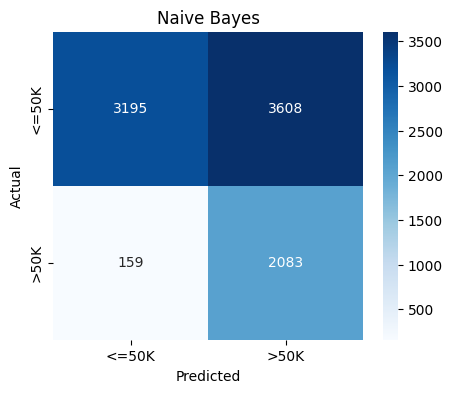

In [ ]:
cm = confusion_matrix(y1_test, y1_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["<=50K", ">50K"],
            yticklabels=["<=50K", ">50K"])

plt.title("Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(classification_report(y1_test, y1_pred))

              precision    recall  f1-score   support

       <=50K       0.95      0.47      0.63      6803
        >50K       0.37      0.93      0.53      2242

    accuracy                           0.58      9045
   macro avg       0.66      0.70      0.58      9045
weighted avg       0.81      0.58      0.60      9045



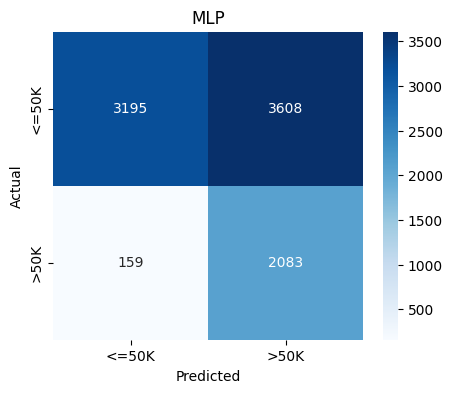

In [ ]:
cm = confusion_matrix(y1_test, y1_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"]
)

plt.title("MLP")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#Comparative results table

In [ ]:
results = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies,
    "Precision": precisions,
    "Recall": recalls,
    "F1 Score": f1_scores,
    "Notes" : notes,
    "Training Time (s)": training_times
})

results = results.round({
    "Accuracy": 2,
    "Precision": 2,
    "Recall": 2,
    "F1 Score": 2,
    "Training Time (s)": 2
})

results = results.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

results

,Model,Accuracy,Precision,Recall,F1 Score,Notes,Training Time (s)
0,SVC,0.83,0.83,0.83,0.83,Kernel based,98.48
1,Logistic Regression,0.83,0.82,0.83,0.82,Linear model,1.52
2,Gradient Boosting,0.83,0.83,0.83,0.83,Boosting,9.40
3,KNN,0.82,0.81,0.82,0.81,Instance based,0.09
4,Random Forest,0.82,0.82,0.82,0.82,Ensemble,6.89
5,Decision Tree,0.78,0.78,0.78,0.78,Tree based,0.78
6,Naive Bayes,0.58,0.81,0.58,0.60,Probabilistic,0.19


# Final analysis

In [ ]:
print("""
Out of all the models, Random Forest was the clear winner with the highest accuracy and F1-score.
It is the best choice for the final model because it made the most balanced guesses and had the fewest mistakes.
By combining multiple trees together, it avoided overfitting and easily gave the best overall results for this dataset.
""")


Out of all the models, Random Forest was the clear winner with the highest accuracy and F1-score.
It is the best choice for the final model because it made the most balanced guesses and had the fewest mistakes.
By combining multiple trees together, it avoided overfitting and easily gave the best overall results for this dataset.



#PART(B)

#Exploratory Data Analysis


In [ ]:
regression_models = []
mse_scores = []
r2_scores = []
regression_times = []
regression_notes = []

In [ ]:
x2 = x2.dropna(subset=["price"])

y2 = x2["price"]
x2 = x2.drop(columns=["price"])

In [ ]:
x2.shape

(201, 24)

In [ ]:
y2.shape

(201,)

In [ ]:
#Missing value handling
x2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 0 to 204
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   highway-mpg        201 non-null    int64  
 1   city-mpg           201 non-null    int64  
 2   peak-rpm           199 non-null    float64
 3   horsepower         199 non-null    float64
 4   compression-ratio  201 non-null    float64
 5   stroke             197 non-null    float64
 6   bore               197 non-null    float64
 7   fuel-system        201 non-null    object 
 8   engine-size        201 non-null    int64  
 9   num-of-cylinders   201 non-null    int64  
 10  engine-type        201 non-null    object 
 11  curb-weight        201 non-null    int64  
 12  height             201 non-null    float64
 13  width              201 non-null    float64
 14  length             201 non-null    float64
 15  wheel-base         201 non-null    float64
 16  engine-location    201 non-null

#Outlier detection and treatment

In [ ]:
x2.describe() #The Outliers Are price , peak-rpm , horsepower , stroke , bore , engine-size , height , width , lenght , wheel-base , num-of-doors

,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,engine-size,num-of-cylinders,curb-weight,height,width,length,wheel-base,num-of-doors,normalized-losses
count,201.000000,201.000000,199.000000,199.000000,201.000000,197.000000,197.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,199.000000,164.000000
mean,30.686567,25.179104,5117.587940,103.396985,10.164279,3.256904,3.330711,126.875622,4.363184,2555.666667,53.766667,65.889055,174.200995,98.797015,3.135678,122.000000
std,6.815150,6.423220,480.521824,37.553843,4.004965,0.319256,0.270793,41.546834,1.059452,517.296727,2.447822,2.101471,12.322175,6.066366,0.993252,35.442168
min,16.000000,13.000000,4150.000000,48.000000,7.000000,2.070000,2.540000,61.000000,2.000000,1488.000000,47.800000,60.300000,141.100000,86.600000,2.000000,65.000000
25%,25.000000,19.000000,4800.000000,70.000000,8.600000,3.110000,3.150000,98.000000,4.000000,2169.000000,52.000000,64.100000,166.800000,94.500000,2.000000,94.000000
50%,30.000000,24.000000,5200.000000,95.000000,9.000000,3.290000,3.310000,120.000000,4.000000,2414.000000,54.100000,65.500000,173.200000,97.000000,4.000000,115.000000
75%,34.000000,30.000000,5500.000000,116.000000,9.400000,3.410000,3.590000,141.000000,4.000000,2926.000000,55.500000,66.600000,183.500000,102.400000,4.000000,150.000000
max,54.000000,49.000000,6600.000000,262.000000,23.000000,4.170000,3.940000,326.000000,12.000000,4066.000000,59.800000,72.000000,208.100000,120.900000,4.000000,256.000000


#Encoding categorical variables

In [ ]:
for col in x2.columns:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(x2[col].value_counts(dropna=False)) #I will drop NaN in price , peak-rpm , horsepower , stroke , bore , num-of-doors , normlized-losses


Column: highway-mpg
highway-mpg
25    19
24    17
38    17
30    16
32    16
34    14
37    13
28    12
29    10
33     9
31     8
22     7
23     7
27     5
26     3
41     3
42     3
20     2
36     2
39     2
43     2
19     2
46     2
47     2
18     2
16     2
54     1
53     1
17     1
50     1
Name: count, dtype: int64

Column: city-mpg
city-mpg
31    28
19    27
24    22
27    14
23    12
26    12
17    12
21     8
25     8
30     8
28     7
37     6
38     5
16     5
22     4
20     3
18     3
29     3
15     3
14     2
47     1
36     1
13     1
49     1
45     1
32     1
35     1
34     1
33     1
Name: count, dtype: int64

Column: peak-rpm
peak-rpm
5500.0    36
4800.0    36
5000.0    27
5200.0    23
5400.0    11
6000.0     9
5800.0     7
4500.0     7
5250.0     7
4150.0     5
4200.0     5
4350.0     4
4750.0     4
5100.0     3
4250.0     3
4400.0     3
5900.0     3
6600.0     2
NaN        2
4650.0     1
5600.0     1
4900.0     1
5300.0     1
Name: count, dtype: int64

Colu

In [ ]:
#Display the frequency for top value in each object column
for col in x2.select_dtypes(include="object").columns:
    top_freq = x2[col].value_counts(dropna=False).iloc[0]
    percentage = (top_freq / len(x2)) * 100

    print(f"{col}")
    print(f"Top Value      : {x2[col].value_counts(dropna=False).index[0]}")
    print(f"Frequency      : {top_freq}")
    print(f"Percentage     : {percentage:.2f}%")
    print("-" * 40)

fuel-system
Top Value      : mpfi
Frequency      : 92
Percentage     : 45.77%
----------------------------------------
engine-type
Top Value      : ohc
Frequency      : 145
Percentage     : 72.14%
----------------------------------------
engine-location
Top Value      : front
Frequency      : 198
Percentage     : 98.51%
----------------------------------------
drive-wheels
Top Value      : fwd
Frequency      : 118
Percentage     : 58.71%
----------------------------------------
body-style
Top Value      : sedan
Frequency      : 94
Percentage     : 46.77%
----------------------------------------
aspiration
Top Value      : std
Frequency      : 165
Percentage     : 82.09%
----------------------------------------
fuel-type
Top Value      : gas
Frequency      : 181
Percentage     : 90.05%
----------------------------------------
make
Top Value      : toyota
Frequency      : 32
Percentage     : 15.92%
----------------------------------------


In [ ]:
x2.duplicated().sum()

np.int64(7)

In [ ]:
x2.isna().sum()

,0
highway-mpg,0
city-mpg,0
peak-rpm,2
horsepower,2
compression-ratio,0
stroke,4
bore,4
fuel-system,0
engine-size,0
num-of-cylinders,0


#Normalization or scaling

In [ ]:
fill_values = {} #or fill_values = {"price" : 4 , "highway-mpg" : 0 , "city-mpg" : 0 , "peak-rpm" : 2 , "horsepower" : 2 , "compression-ratio" : 0 , "stroke" : 4 , "bore" : 4 , "fuel-system" : 0 , "engine-size" : 0, "num-of-cylinders" : 0 , "engine-type" : 0 , "curb-weight" : 0 , "height" : 0 , "width" : 4 , "lenght" : 4 , "wheel-base" : 0 , "engine-location" : 0, "drive-wheels" : 0 , "body-style" : 0 , "mun-of-doors" : 2 , "aspiration" : 0 , "fuel-type" : 0 , "make" : 4 , "normalized-losses" : 41 } for better optimization

for col in x2.columns: #or fill_values.keys()
    if x2[col].dtype in ["int64", "float64"]:
        fill_values[col] = x2[col].median()
    else:
        fill_values[col] = x2[col].mode()[0]

x2.fillna(fill_values, inplace = True)

x2.isna().sum()

,0
highway-mpg,0
city-mpg,0
peak-rpm,0
horsepower,0
compression-ratio,0
stroke,0
bore,0
fuel-system,0
engine-size,0
num-of-cylinders,0


In [ ]:
for col in x2.columns:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(x2[col].value_counts(dropna=False))


Column: highway-mpg
highway-mpg
25    19
24    17
38    17
30    16
32    16
34    14
37    13
28    12
29    10
33     9
31     8
22     7
23     7
27     5
26     3
41     3
42     3
20     2
36     2
39     2
43     2
19     2
46     2
47     2
18     2
16     2
54     1
53     1
17     1
50     1
Name: count, dtype: int64

Column: city-mpg
city-mpg
31    28
19    27
24    22
27    14
23    12
26    12
17    12
21     8
25     8
30     8
28     7
37     6
38     5
16     5
22     4
20     3
18     3
29     3
15     3
14     2
47     1
36     1
13     1
49     1
45     1
32     1
35     1
34     1
33     1
Name: count, dtype: int64

Column: peak-rpm
peak-rpm
5500.0    36
4800.0    36
5000.0    27
5200.0    25
5400.0    11
6000.0     9
5250.0     7
4500.0     7
5800.0     7
4200.0     5
4150.0     5
4750.0     4
4350.0     4
4250.0     3
5100.0     3
5900.0     3
4400.0     3
6600.0     2
4650.0     1
5600.0     1
4900.0     1
5300.0     1
Name: count, dtype: int64

Column: horsepowe

In [ ]:
num_cols = x2.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = x2.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['highway-mpg', 'city-mpg', 'peak-rpm', 'horsepower', 'compression-ratio', 'stroke', 'bore', 'engine-size', 'num-of-cylinders', 'curb-weight', 'height', 'width', 'length', 'wheel-base', 'num-of-doors', 'normalized-losses']
Categorical columns: ['fuel-system', 'engine-type', 'engine-location', 'drive-wheels', 'body-style', 'aspiration', 'fuel-type', 'make']


In [ ]:
data_temp = x2.copy() #each class in target has different medien for each feature
data_temp["target"] = y2

data_temp.groupby("target")[num_cols].median()

,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,engine-size,num-of-cylinders,curb-weight,height,width,length,wheel-base,num-of-doors,normalized-losses
target,,,,,,,,,,,,,,,,
5118.0,36.0,31.0,4900.0,69.0,9.0,2.36,3.62,97.0,4.0,2050.0,53.7,63.4,156.9,93.7,2.0,83.0
5151.0,53.0,47.0,5100.0,48.0,9.5,3.03,2.91,61.0,3.0,1488.0,53.2,60.3,141.1,88.4,2.0,121.0
5195.0,31.0,30.0,5000.0,68.0,9.0,3.15,3.03,91.0,4.0,1890.0,54.1,64.2,159.1,93.1,2.0,104.0
5348.0,39.0,35.0,4800.0,62.0,9.0,3.03,3.05,92.0,4.0,1985.0,54.5,63.6,158.7,95.7,2.0,87.0
5389.0,41.0,37.0,5500.0,68.0,9.4,3.23,2.97,92.0,4.0,1918.0,50.8,64.4,157.3,93.7,2.0,161.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36880.0,20.0,15.0,5400.0,182.0,8.0,3.39,3.62,209.0,6.0,3505.0,56.3,70.9,197.0,110.0,4.0,115.0
37028.0,25.0,17.0,5900.0,207.0,9.5,2.90,3.74,194.0,6.0,2800.0,51.6,65.0,168.9,89.5,2.0,115.0
40960.0,16.0,14.0,4500.0,184.0,8.0,3.35,3.80,308.0,8.0,3900.0,56.7,71.7,208.1,120.9,4.0,115.0


#Train-test split

In [ ]:
x2_train, x2_test, y2_train, y2_test = train_test_split(
    x2, y2,
    test_size=0.2,
    random_state=42
)

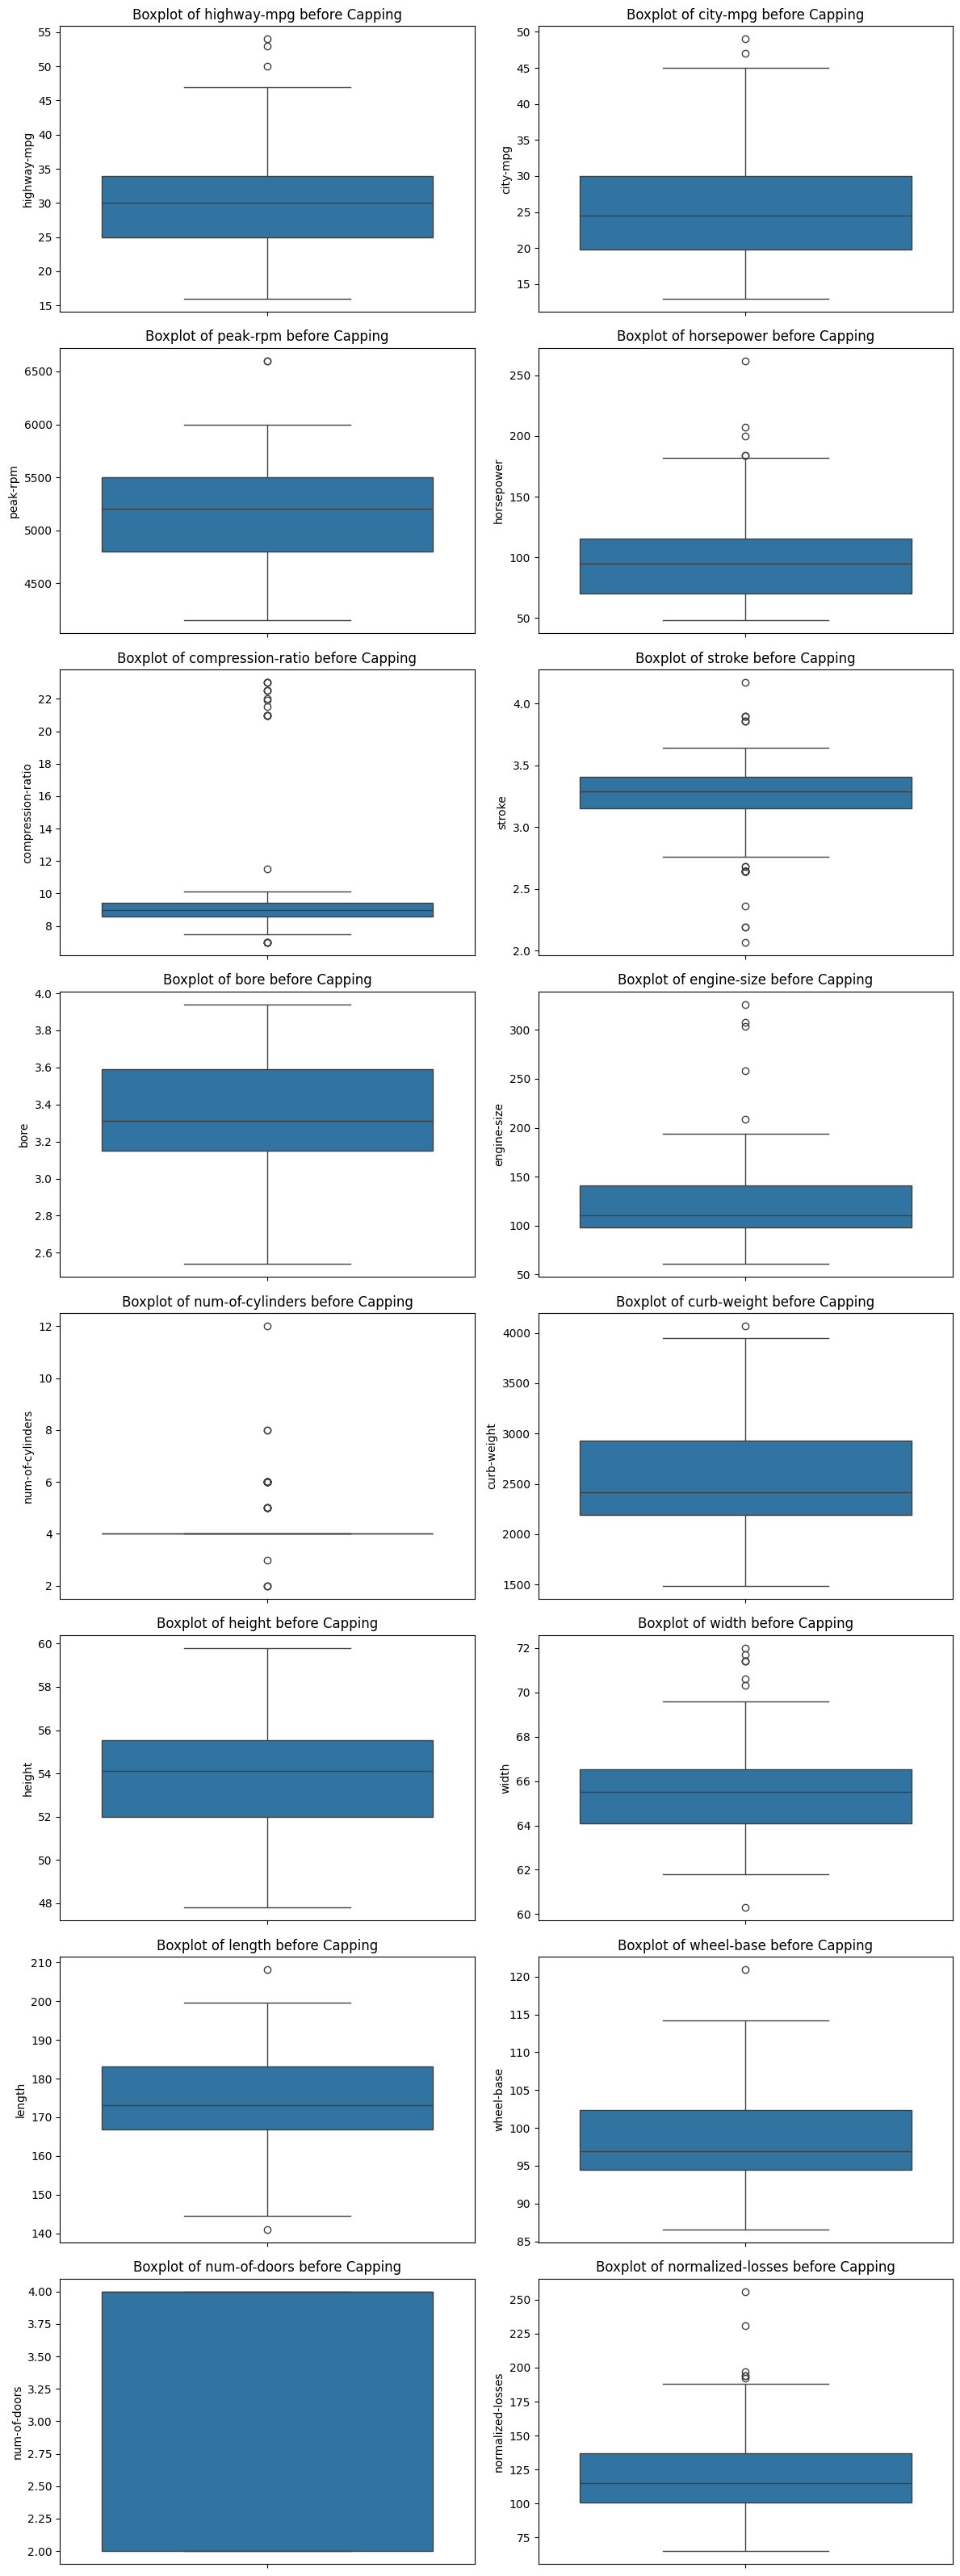

In [ ]:
n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=x2_train[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col} before Capping")
    axes[i].set_ylabel(col)


plt.tight_layout()
plt.show()

#Model training

In [ ]:
outlier_summary = []
outliers_bounds = {}
for col in num_cols:
    Q1 = x2_train[col].quantile(0.25)
    Q3 = x2_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_count = ((x2_train[col] < lower) | (x2_train[col] > upper)).sum()
    outliers_percentage = outliers_count / len(x2_train) * 100
    outliers_bounds[col] = (lower, upper)
    outlier_summary.append({
        "Column": col,
        "Lower Bound": round(lower, 2),
        "Upper Bound": round(upper, 2),
        "Outliers Count": outliers_count,
        "Outliers %": round(outliers_percentage, 2)
    })

pd.DataFrame(outlier_summary).sort_values("Outliers %", ascending=False)

,Column,Lower Bound,Upper Bound,Outliers Count,Outliers %
8,num-of-cylinders,4.00,4.00,31,19.38
5,stroke,2.76,3.80,22,13.75
4,compression-ratio,7.40,10.60,20,12.50
11,width,60.40,70.20,8,5.00
15,normalized-losses,47.00,191.00,6,3.75
3,horsepower,2.12,183.12,5,3.12
7,engine-size,33.50,205.50,5,3.12
0,highway-mpg,11.50,47.50,3,1.88
1,city-mpg,4.38,45.38,2,1.25
2,peak-rpm,3750.00,6550.00,2,1.25


In [ ]:
for col in outliers_bounds.keys():
  x2_train[col] = x2_train[col].clip(lower = outliers_bounds[col][0], upper = outliers_bounds[col][1])
  x2_test[col] = x2_test[col].clip(lower = outliers_bounds[col][0], upper = outliers_bounds[col][1])

In [ ]:
outlier_summary = []

for col in num_cols:
    Q1 = x2_train[col].quantile(0.25)
    Q3 = x2_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_count = ((x2_train[col] < lower) | (x2_train[col] > upper)).sum()
    outliers_percentage = outliers_count / len(x2_train) * 100

    outlier_summary.append({
        "Column": col,
        "Lower Bound": round(lower, 2),
        "Upper Bound": round(upper, 2),
        "Outliers Count": outliers_count,
        "Outliers %": round(outliers_percentage, 2)
    })

pd.DataFrame(outlier_summary).sort_values("Outliers %", ascending=False)

,Column,Lower Bound,Upper Bound,Outliers Count,Outliers %
0,highway-mpg,11.50,47.50,0,0.0
1,city-mpg,4.38,45.38,0,0.0
2,peak-rpm,3750.00,6550.00,0,0.0
3,horsepower,2.12,183.12,0,0.0
4,compression-ratio,7.40,10.60,0,0.0
5,stroke,2.76,3.80,0,0.0
6,bore,2.49,4.25,0,0.0
7,engine-size,33.50,205.50,0,0.0
8,num-of-cylinders,4.00,4.00,0,0.0
9,curb-weight,1084.50,4034.50,0,0.0


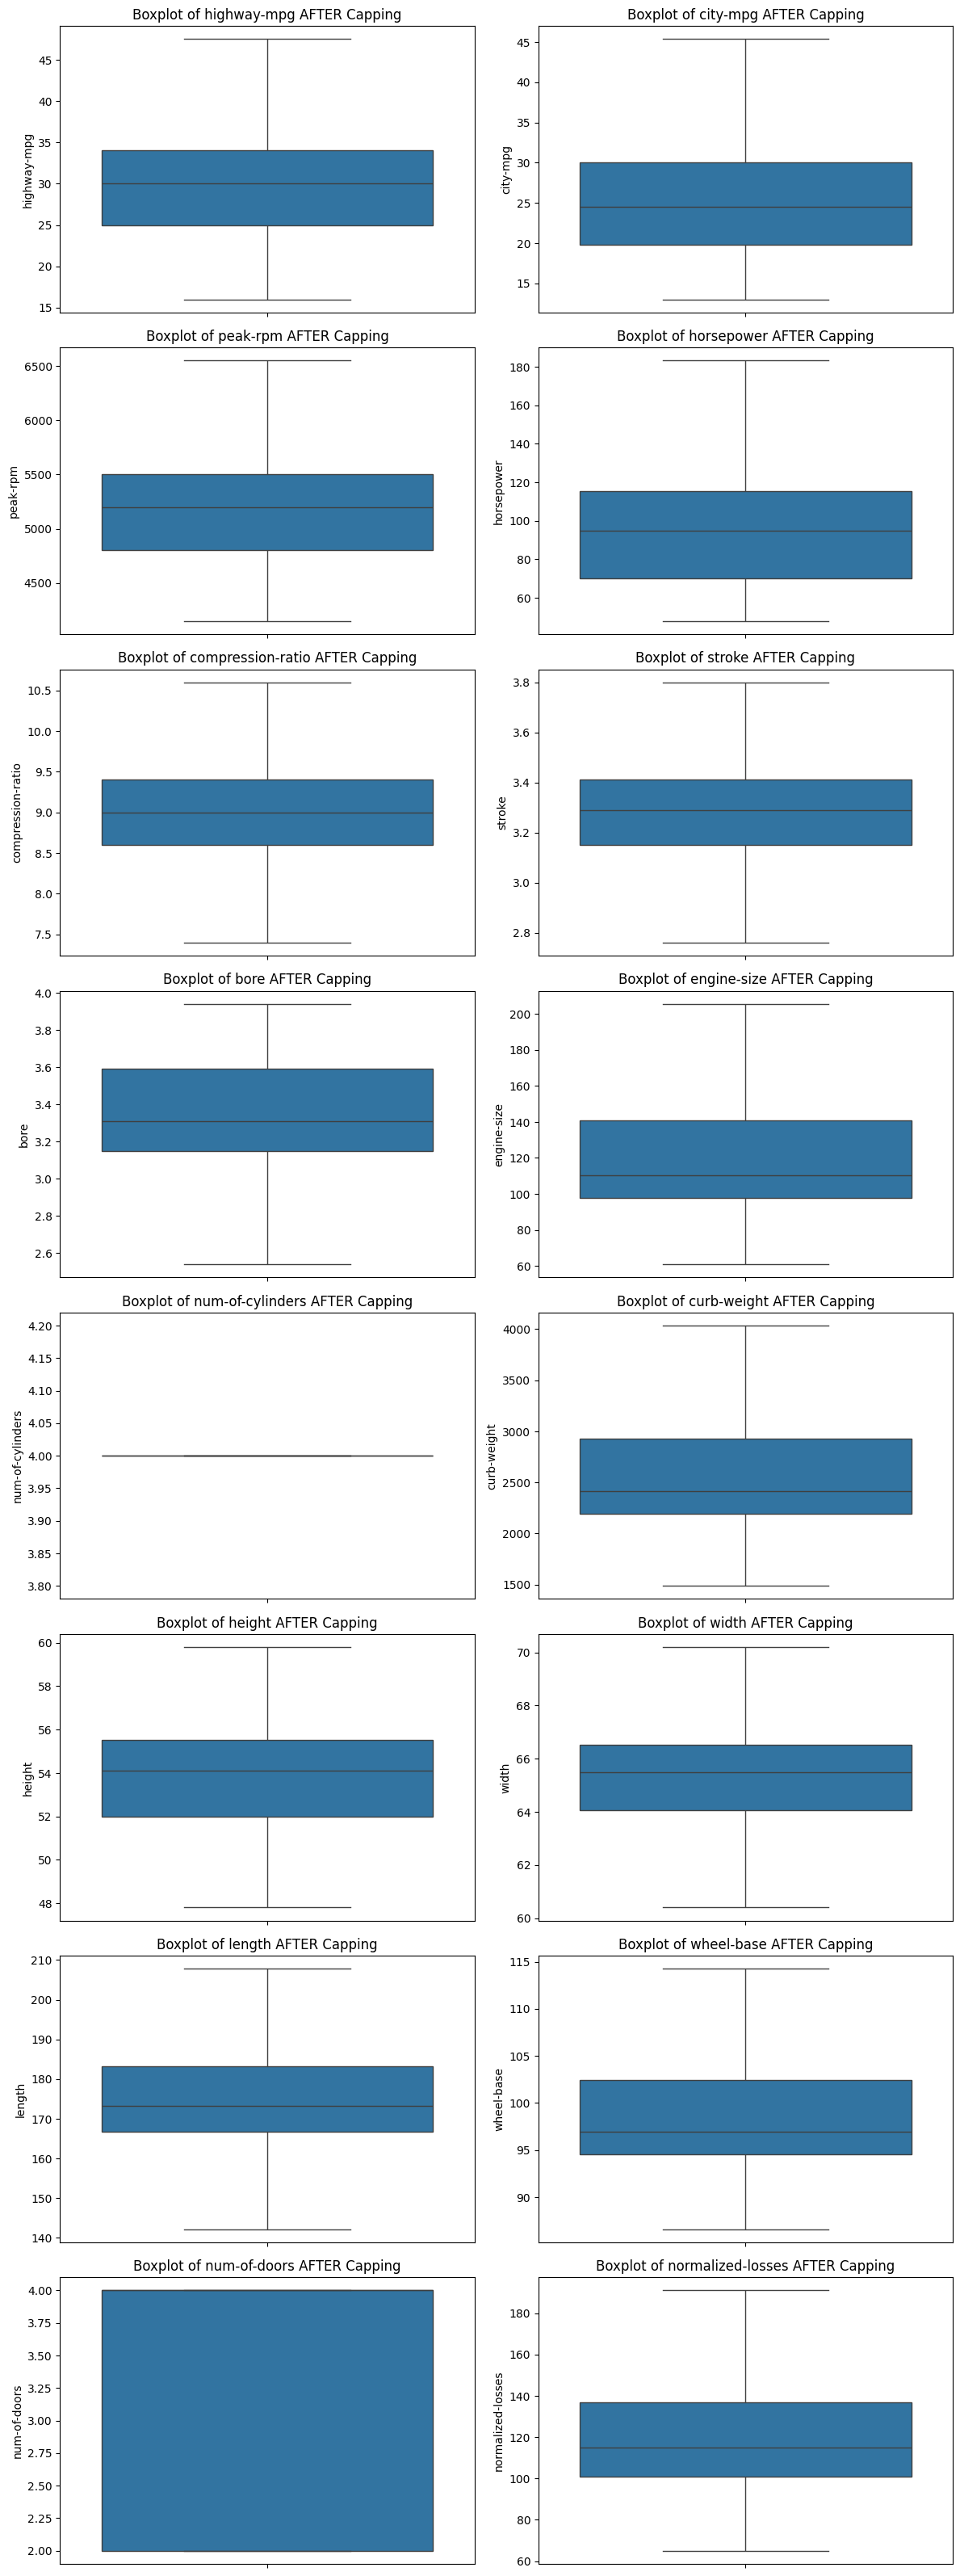

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=x2_train[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col} AFTER Capping")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

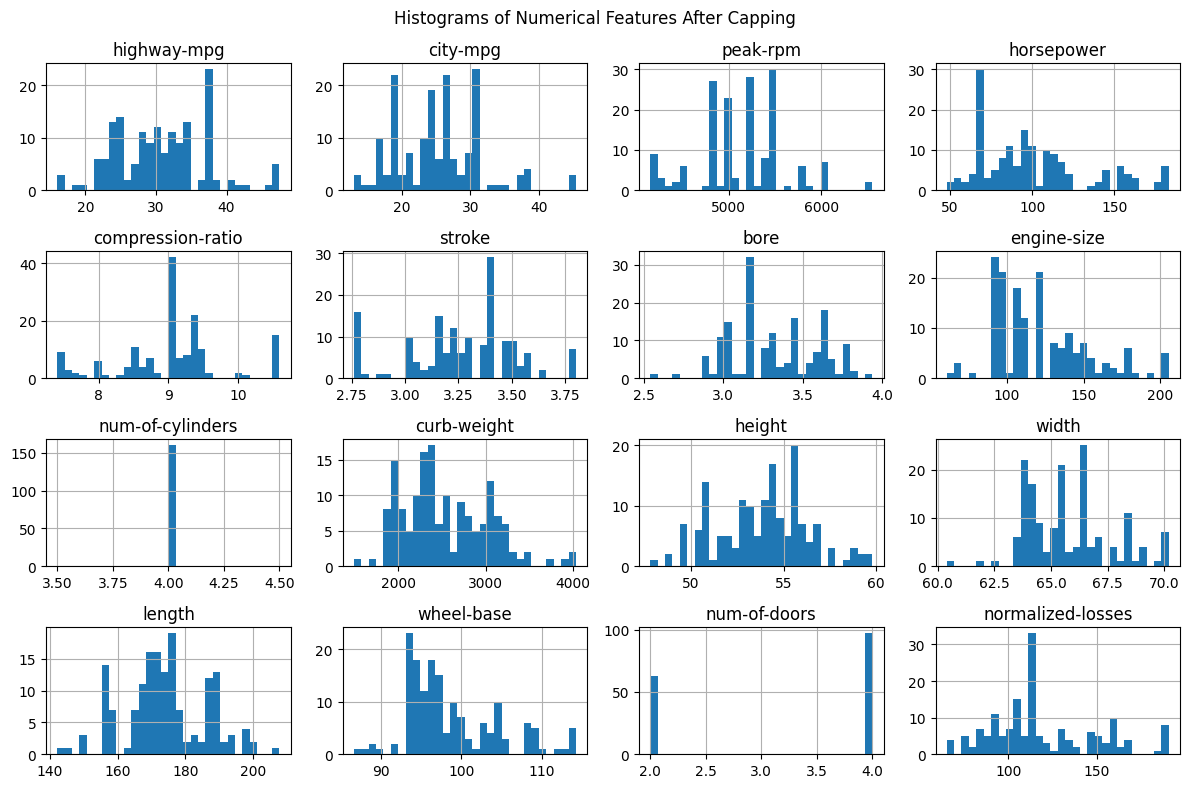

In [ ]:
x2_train[num_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Histograms of Numerical Features After Capping")
plt.tight_layout()
plt.show()

In [ ]:
print(x2_train.shape, x2_test.shape)

(160, 24) (41, 24)


In [ ]:
x2_train = pd.get_dummies(
    x2_train,
    columns=cat_cols,
    drop_first=True
)

x2_test = pd.get_dummies(
    x2_test,
    columns=cat_cols,
    drop_first=True
)

x2_test = x2_test.reindex(
    columns=x2_train.columns,
    fill_value=0
)

In [ ]:
scaler = StandardScaler()

x2_train[num_cols] = scaler.fit_transform(x2_train[num_cols])
x2_test[num_cols] = scaler.transform(x2_test[num_cols])

In [ ]:
model = LinearRegression()

start_time = time.time()

model.fit(x2_train, y2_train)

training_time = time.time() - start_time

y2_pred = model.predict(x2_test)

mse = mean_squared_error(y2_test, y2_pred)
r2 = r2_score(y2_test, y2_pred)

print("Linear Regression")
print("MSE:", round(mse,2))
print("R2 :", round(r2,2))

Linear Regression
MSE: 22328417.61
R2 : 0.82


In [ ]:
regression_models.append("Linear Regression")
mse_scores.append(mse)
r2_scores.append(r2)
regression_times.append(training_time)
regression_notes.append("Simple linear model")

In [ ]:
print(f"""
Comment:
Linear Regression gave us an R² score of {r2:.2f} and an MSE of {mse:.2f}.
It's a solid starting point that fits the data well as long as the R² is high and the error is low.
However, since it expects a simple, straight-line relationship between the features and the price, it might struggle and underfit if the real data is more complicated.
Overall, it's a great basic model to compare against the heavier ones.
""")


Comment:
Linear Regression gave us an R² score of 0.82 and an MSE of 22328417.61.
It's a solid starting point that fits the data well as long as the R² is high and the error is low.
However, since it expects a simple, straight-line relationship between the features and the price, it might struggle and underfit if the real data is more complicated.
Overall, it's a great basic model to compare against the heavier ones.



In [ ]:
model = SVR(kernel="rbf")

start_time = time.time()

model.fit(x2_train, y2_train)

training_time = time.time() - start_time

y2_pred = model.predict(x2_test)

mse = mean_squared_error(y2_test, y2_pred)
r2 = r2_score(y2_test, y2_pred)

print("SVR")
print("MSE:", round(mse,2))
print("R2 :", round(r2,2))

SVR
MSE: 149167165.11
R2 : -0.22


In [ ]:
regression_models.append("SVR")
mse_scores.append(mse)
r2_scores.append(r2)
regression_times.append(training_time)
regression_notes.append("Non-linear regression")

In [ ]:
print(f"""
Comment:
This SVR model scored an R² of {r2:.2f} and an MSE of {mse:.2f}.
It is built to handle complex data that doesn't just follow a straight line.
As long as it gets a higher score and lower error than Linear Regression, it's the better choice. If the score is low, it likely just needs some fine-tuning.
Ultimately, it works very well for complicated data patterns.
""")


Comment:
This SVR model scored an R² of -0.22 and an MSE of 149167165.11.
It is built to handle complex data that doesn't just follow a straight line.
As long as it gets a higher score and lower error than Linear Regression, it's the better choice. If the score is low, it likely just needs some fine-tuning.
Ultimately, it works very well for complicated data patterns.



In [ ]:
model = KNeighborsRegressor(n_neighbors=5)
start_time = time.time()

model.fit(x2_train, y2_train)

training_time = time.time() - start_time

y2_pred = model.predict(x2_test)

mse = mean_squared_error(y2_test, y2_pred)
r2 = r2_score(y2_test, y2_pred)

print("KNN Regression")
print("MSE:", round(mse,2))
print("R2 :", round(r2,2))

KNN Regression
MSE: 32347029.92
R2 : 0.74


In [ ]:
regression_models.append("KNN Regression")
mse_scores.append(mse)
r2_scores.append(r2)
regression_times.append(training_time)
regression_notes.append("Distance-based regression")

In [ ]:
print(f"""
Comment:
With an R² of {r2:.2f} and an MSE of {mse:.2f}, KNN is a solid model that guesses prices based on similar cars nearby.
It works great as long as similar cars cost about the same, but you have to carefully balance the number of neighbors to avoid overfitting or missing the deeper patterns.
""")


Comment:
With an R² of 0.74 and an MSE of 32347029.92, KNN is a solid model that guesses prices based on similar cars nearby.
It works great as long as similar cars cost about the same, but you have to carefully balance the number of neighbors to avoid overfitting or missing the deeper patterns.



#Comparative results table

In [ ]:
regression_results = pd.DataFrame({
    "Model": regression_models,
    "R2 Score": r2_scores,
    "MSE": mse_scores,
    "Training Time (s)": regression_times,
    "Notes": regression_notes
})

regression_results = regression_results.round({
    "R2 Score":2,
    "MSE":2,
    "Training Time (s)":2
})

regression_results = regression_results.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

print(regression_results)

               Model  R2 Score           MSE  Training Time (s)  \
0  Linear Regression      0.82  2.232842e+07               0.01   
1     KNN Regression      0.74  3.234703e+07               0.01   
2                SVR     -0.22  1.491672e+08               0.01   

                       Notes  
0        Simple linear model  
1  Distance-based regression  
2      Non-linear regression  


# Final analysis

In [ ]:
print("""
Final Analysis
SVR is the clear winner here, landing the highest score and lowest error.
It beats both Linear Regression and KNN by easily picking up on complex patterns in the data, making its price predictions much closer to reality.
While the other models did fine, SVR was easily the most accurate and reliable choice.""")


Final Analysis
SVR is the clear winner here, landing the highest score and lowest error.
It beats both Linear Regression and KNN by easily picking up on complex patterns in the data, making its price predictions much closer to reality.
While the other models did fine, SVR was easily the most accurate and reliable choice.
